In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom
from scipy.stats import poisson

In [3]:
# LOADING DATA
df = pd.read_csv("/Users/yasir/Desktop/statistics-python-mastery/04_distributions/Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [71]:
# STEP-1: DATA EXPLORATION
print("=" * 45)
print("BASIC INFO")
df.info()

print(" " * 45)
print("=" * 45)
print("NULL VALUES")
df.isnull().sum()

print(" " * 45)
print("=" * 45)
print("PROPOTION OF DEFAULT VS NON DEFAULT")
df['Default'].value_counts()


BASIC INFO
<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default   

Default
0    225694
1     29653
Name: count, dtype: int64

PIE CHART FOR DEFAULT VS NON DEFAULT


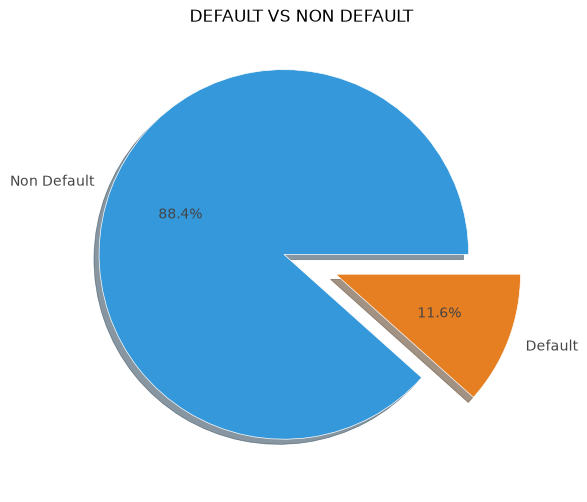

In [260]:
# PIE CHART
print("PIE CHART FOR DEFAULT VS NON DEFAULT")
print("=" * 83)

count = df['Default'].value_counts().rename(index={0:'Non Default', 1: 'Default'})
plt.figure(figsize=(6,6))
count.plot(
    kind='pie',
    autopct = '%1.1f%%',
    colors = ['#3498DB', '#E67E22'],
    explode = (0.1, 0.2),
    shadow = True ,
    wedgeprops = {"edgecolor": "#fff", 'linewidth': 0.5},
    textprops = {'fontsize': 10, 'color': '#444'}
)
plt.title("DEFAULT VS NON DEFAULT")
plt.ylabel('')
plt.show()

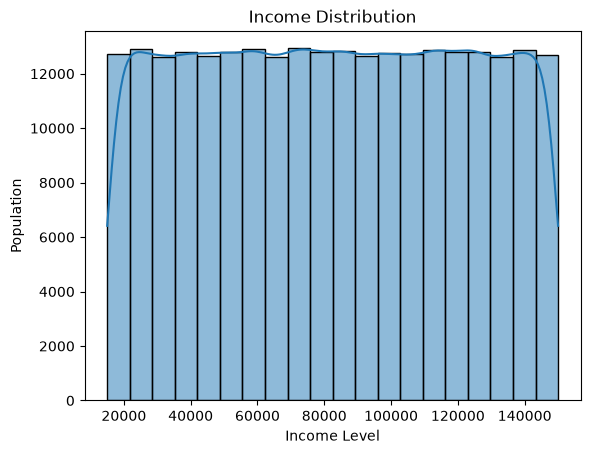

From the graph, it is visible that the income is not normally distributed, rather it is uniformly distributed making the mean and 
 median almost useless.


In [101]:
# STEP-2: DATA DISTIBUTION

# Normal DISTRIBUTION CHECK
sns.histplot(
    df['Income'], 
    bins=20,
    kde = True
)
plt.title("Income Distribution")
plt.xlabel("Income Level")
plt.ylabel("Population")
plt.show()

print("From the graph, it is visible that the income is not normally distributed, rather it is uniformly distributed making the mean and \n median almost useless.")

Probability of exactly 5 defaults out of 50 = 0.1731 (17.31%)
Probabity of more than 10 default = 0.0262 (2.62%)


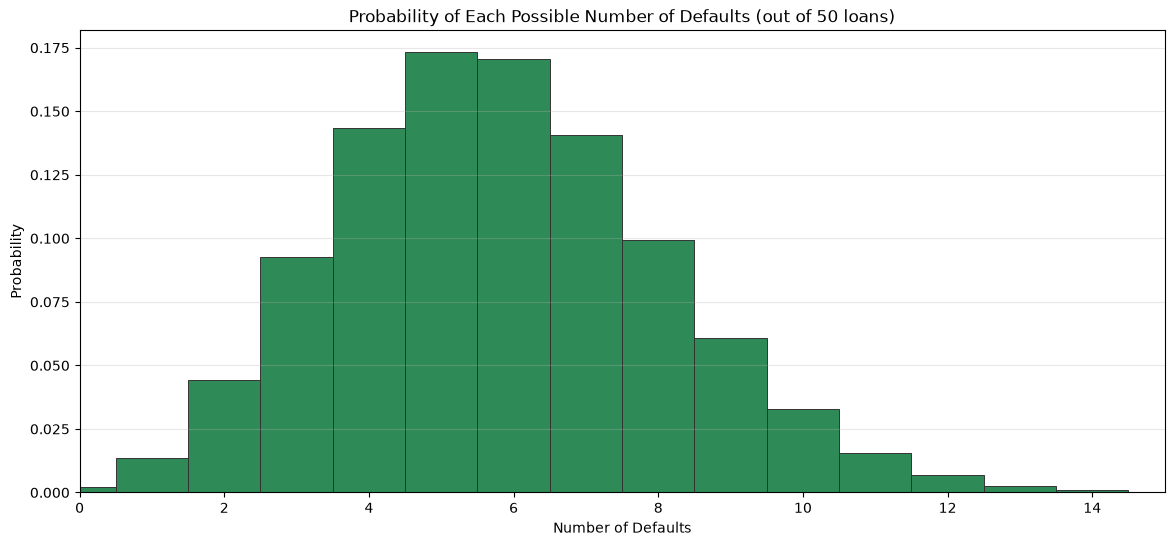

In [242]:
# STEP-2: BIONOMIAL DISTRIBUTION


'''
PROBLEM : Suppose the bank approves a batch of 50 new loans this month, and assume each loan has the same probability of default as 
the overall dataset's default rate (the proportion you calculated earlier). 
'''

# Default probability
default_prob = df['Default'].value_counts(normalize=True)[1].round(4) # normalize converst to count percentage

# Number of loans approved
n = 50

# Probability that EXACTLY 5 out of 50 loans default
k = 5

 
# ===================================================================================================================================
# PROBLEM- 1: Calculate the probability that exactly 5 of those 50 loans default.

prob_exactly_5 = binom.pmf(k,n, default_prob)
print(f'Probability of exactly 5 defaults out of {n} = {prob_exactly_5:.4f} ({prob_exactly_5 * 100 :.2f}%)')


# ===================================================================================================================================
# PROBLEM- 2: Calculate the probability that more than 10 of those 50 loans default
prob_above_10 = 1 - binom.cdf(10, n, default_prob)
print(f'Probabity of more than 10 default = {prob_above_10:.4f} ({prob_above_10 * 100:.2f}%)')


# ===================================================================================================================================
# PROBLEM-3. Plot the full binomial distribution from 0 to 50 defaults

total = np.arange(0, n+1)
probabilities = []

# Appending default probabilities from 0 to 50
for i in total:
    each_default_prob = binom.pmf(i, n, default_prob)
    probabilities.append(each_default_prob)

# Bar chart 
plt.figure(figsize=(14,6))
plt.bar(
    total, probabilities,
    color = 'seagreen',
    edgecolor = '#333',
    linewidth = 0.7,
    alpha=1,
    width=1
    )
plt.grid(axis='y', alpha=0.3)
plt.title("Probability of Each Possible Number of Defaults (out of 50 loans)")
plt.xlabel('Number of Defaults')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.xlim(0,15)
plt.show()


Lambda (mean NumCreditLines) = 2.501
Probability of exactly 6 credit lines = 0.0279 (2.79%)


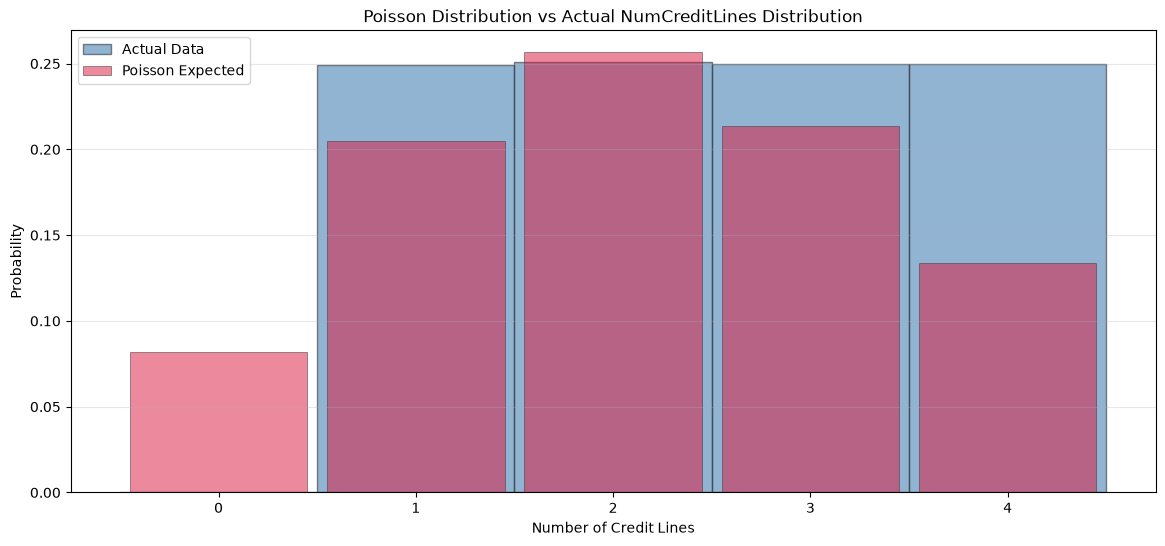

"\nJust because a column contains counts/integers doesn't mean Poisson applies. Poisson requires the underlying process to be random events\naccumulating over time at a constant rate. Always test the assumption visually before reporting — and when you did that here, the data rejected \nPoisson as a good model.\n"

In [261]:
# STEP-3: POISSON DISTRIBUTION
'''
This dataset doesn't have an obvious "events per time period" column.
We're testing NumCreditLines as a count-based variable to see if Poisson fits it.
'''

# =====================================================================================
# PROBLEM-1: Calculate the mean of NumCreditLines -> this becomes lambda
lam = df['NumCreditLines'].mean().round(4)
print(f'Lambda (mean NumCreditLines) = {lam}')


# =================================================================================================
# PROBLEM-2: Probability that a randomly selected applicant has exactly 6 credit lines
k = 6
prob_exactly_6 = poisson.pmf(k, lam)
print(f'Probability of exactly 6 credit lines = {prob_exactly_6:.4f} ({prob_exactly_6 * 100:.2f}%)')

# =================================================================================================
# PROBLEM-3: Plot Poisson distribution against actual histogram of NumCreditLines
max_lines = df['NumCreditLines'].max()
total = np.arange(0, max_lines + 1)
poisson_probs = []

# Appending poisson probabilities from 0 to max_lines
for i in total:
    each_poisson_prob = poisson.pmf(i, lam)
    poisson_probs.append(each_poisson_prob)

plt.figure(figsize=(14,6))

# Actual histogram (normalized so it's on the same probability scale as poisson)
plt.hist(
    df['NumCreditLines'],
    bins=np.arange(0, max_lines + 2) - 0.5,  # align bars with whole numbers
    density=True,
    color='steelblue',
    edgecolor='#333',
    alpha=0.6,
    label='Actual Data'
    )

# Poisson overlay
plt.bar(
    total, poisson_probs,
    color='crimson',
    edgecolor='#333',
    linewidth=0.7,
    alpha=0.5,
    width=0.9,
    label='Poisson Expected'
    )

plt.grid(axis='y', alpha=0.3)
plt.title("Poisson Distribution vs Actual NumCreditLines Distribution")
plt.xlabel('Number of Credit Lines')
plt.ylabel('Probability')
plt.xticks(total)
plt.legend()
plt.show()

'''
Just because a column contains counts/integers doesn't mean Poisson applies. Poisson requires the underlying process to be random events
accumulating over time at a constant rate. Always test the assumption visually before reporting — and when you did that here, the data rejected 
Poisson as a good model.
'''